# Single-unit responses to social and non-social fixations

**Thesis chapter results — part 1.**

Neurons were recorded simultaneously from the basolateral amygdala (BLA) together
with one of three prefrontal regions — gyral anterior cingulate cortex (ACCg),
dorsomedial prefrontal cortex (dmPFC), or orbitofrontal cortex (OFC) — while two
macaques freely viewed one another. Every fixation falls into one of three
categories: **interactive face**, **non-interactive face**, or **object**.

The chapter argues in five steps:

| § | Claim |
|---|---|
| 2 | Individual neurons fire preferentially for interactive face fixations. |
| 3 | But units are not simply "interactive-face cells" — they separate every pair of categories. |
| 4 | Across the modulated population, interactive face is nevertheless the most frequently preferred category. |
| 5 | Interactive-face responses are held longer, in BLA and OFC. |
| 6 | Responses vary along two independent axes — duration and peak isolation — with no clean cell types. |

Every figure is one row of four region panels, saved as an Illustrator-editable
PDF (embedded TrueType, no clipping masks) plus a 400 dpi PNG. All plotting lives
in `src/dal_monte_2022_analysis/ephys/plotting/`; this notebook orchestrates and
displays only.

## 1 · Setup

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from dal_monte_2022_analysis.config.load import load_config
from dal_monte_2022_analysis.ephys.plotting import thesis_common as style
from dal_monte_2022_analysis.ephys.plotting import thesis_single_unit as figs
from dal_monte_2022_analysis.ephys.plotting import thesis_single_unit_data as data
from dal_monte_2022_analysis.ephys.plotting import thesis_metric_space as space
from dal_monte_2022_analysis.ephys.plotting import thesis_trace_metrics as metrics
from dal_monte_2022_analysis.ephys.analysis.fixation_peakiness import (
    decompose_dominant_peak_prominence,
)

DATASET_CFG_PATH = repo_root / "configs" / "dataset.yaml"
PLOTTING_CFG_PATH = repo_root / "configs" / "plotting.yaml"
PSTH_CFG_PATH = repo_root / "configs" / "ephys_fixation_psth.yaml"

dataset_cfg = load_config(DATASET_CFG_PATH)
plotting_cfg = load_config(PLOTTING_CFG_PATH)
psth_cfg = load_config(PSTH_CFG_PATH)

style.apply_thesis_plot_style(plotting_cfg)
pd.set_option("display.width", 190)
pd.set_option("display.max_columns", 60)

ANALYSIS_ROOT = data.resolve_psth_analysis_root(dataset_cfg)
FIGURE_SETTINGS = style.ThesisFigureSettings(output_dir=ANALYSIS_ROOT / "single_unit_thesis")
FIGURE_SETTINGS.output_dir.mkdir(parents=True, exist_ok=True)

FIGURE_MANIFEST: dict[str, dict[str, Path]] = {}

In [2]:
units = data.load_thesis_unit_table(ANALYSIS_ROOT)
pair_selectivity = data.load_pair_selectivity(ANALYSIS_ROOT)
condition_traces = data.load_condition_traces(ANALYSIS_ROOT)
trace_shape = data.load_trace_shape_table(ANALYSIS_ROOT, units)
trace_shape_all = data.load_trace_shape_table(ANALYSIS_ROOT, units, condition="all")
matched_cv, matched_cv_stats, cv_inflation = data.load_trial_matched_cv(ANALYSIS_ROOT)

unit_plot_settings = data.build_unit_plot_settings(
    DATASET_CFG_PATH, PLOTTING_CFG_PATH, psth_cfg
)
peakiness_settings = data.build_peakiness_settings(DATASET_CFG_PATH, psth_cfg)

print(f"{len(units)} units | {units['is_selective'].sum()} fixation-category-modulated")
print(f"{units['date'].nunique()} sessions | figures -> {FIGURE_SETTINGS.output_dir}")

1201 units | 574 fixation-category-modulated
42 sessions | figures -> /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/psth/single_unit_thesis


## 2 · Neurons fire preferentially for interactive face fixations

Four example units, one per region, each significant on **both** interactive-face
contrasts (int vs non-int face, and int vs object) after FDR correction, and each
firing most for interactive face across the whole fixation window. Panel subtitles
give the mean rate for interactive / non-interactive / object.

Rasters are subsampled to 70 trials per category so individual spikes stay
visible; the firing-rate traces use all trials (mean ± SEM, 10 ms bins, 20 ms
Gaussian smoothing). The three grey bars mark the analysis windows used in §3.

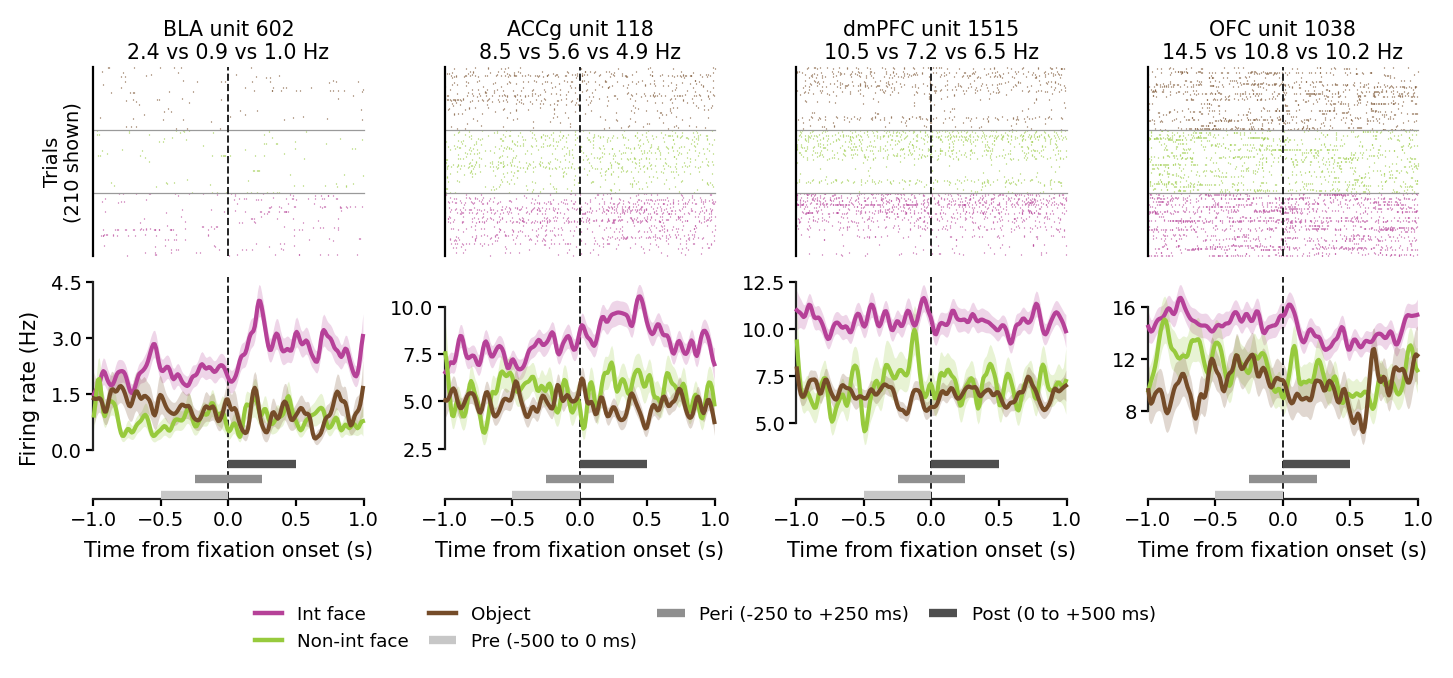

,region_label,uuid,date,subtitle,dominant_condition,n_selective_pairs
0,BLA,602,2062018,2.4 vs 0.9 vs 1.0 Hz,face_interactive,2
1,ACCg,118,1172018,8.5 vs 5.6 vs 4.9 Hz,face_interactive,3
2,dmPFC,1515,2072018,10.5 vs 7.2 vs 6.5 Hz,face_interactive,2
3,OFC,1038,2062018,14.5 vs 10.8 vs 10.2 Hz,face_interactive,2


In [3]:
INT_FACE_EXAMPLES = {"bla": "602", "accg": "118", "dmpfc": "1515", "ofc": "1038"}

example_units = data.build_exemplar_table(
    units, {region: {"int_face": uuid} for region, uuid in INT_FACE_EXAMPLES.items()}
)
window_means = pd.read_csv(
    ANALYSIS_ROOT / "fixation_psth_selectivity" / "condition_window_means.csv"
)
window_means = window_means.loc[window_means["window_name"] == "full_fix"]
example_units = example_units.merge(
    window_means.loc[
        :,
        ["unit_key", "mean_fr_face_interactive_hz", "mean_fr_face_non_interactive_hz",
         "mean_fr_object_hz"],
    ],
    on="unit_key",
    how="left",
)
example_units["subtitle"] = example_units.apply(
    lambda row: (
        f"{row.mean_fr_face_interactive_hz:.1f} vs "
        f"{row.mean_fr_face_non_interactive_hz:.1f} vs "
        f"{row.mean_fr_object_hz:.1f} Hz"
    ),
    axis=1,
)

example_specs = data.build_example_unit_panel_specs(
    example_units,
    style="int_face",
    unit_settings=unit_plot_settings,
    peakiness_settings=peakiness_settings,
    condition_traces=condition_traces,
    subtitle_column="subtitle",
)
fig = figs.plot_example_unit_panel(example_specs, show_window_legend=True)
FIGURE_MANIFEST["fig01_interactive_face_examples"] = style.save_thesis_figure(
    fig, FIGURE_SETTINGS, "fig01_interactive_face_examples"
)
display(Image(data=style.figure_to_png_bytes(fig)))
display(
    example_units.loc[
        :, ["region_label", "uuid", "date", "subtitle", "dominant_condition", "n_selective_pairs"]
    ]
)

## 3 · Units are not simply "interactive-face cells"

A unit counts as **fixation-category-modulated** if its firing rate differs
significantly between at least one category pair in at least one of three 500 ms
windows (Welch's *t*-test on per-trial window means, FDR corrected across all
pair × window tests within the unit).

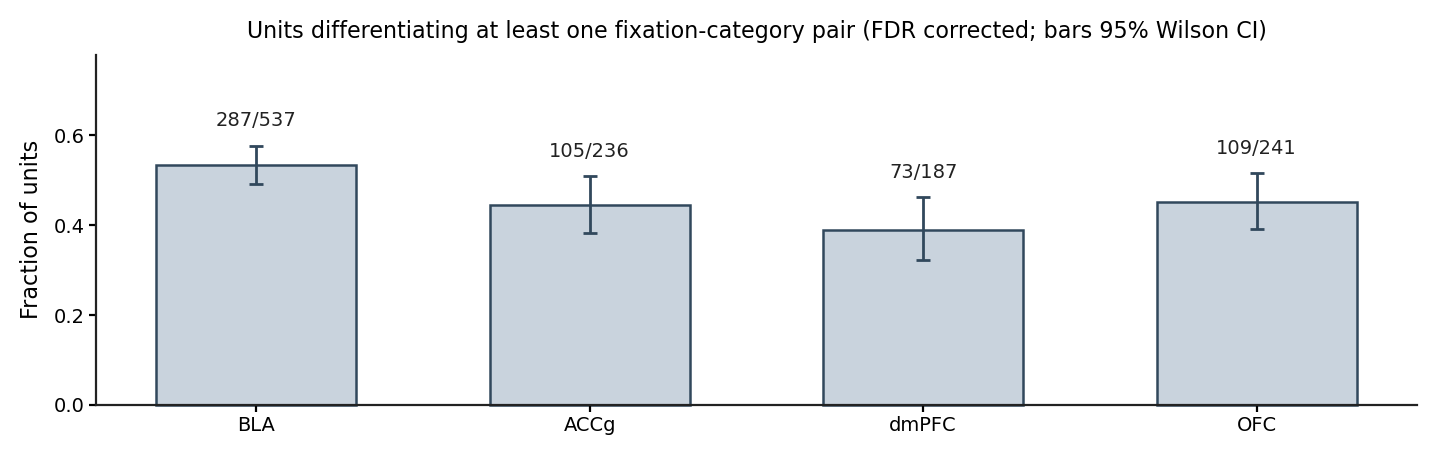

,region,region_label,n_units,n_selective,fraction,ci_low,ci_high,n_sessions
0,bla,BLA,537,287,0.534,0.492,0.576,35
1,accg,ACCg,236,105,0.445,0.383,0.509,19
2,dmpfc,dmPFC,187,73,0.390,0.323,0.462,17
3,ofc,OFC,241,109,0.452,0.391,0.515,14


In [4]:
fig, yield_table = figs.plot_unit_yield_panel(units)
FIGURE_MANIFEST["fig02_unit_yield"] = style.save_thesis_figure(
    fig, FIGURE_SETTINGS, "fig02_unit_yield"
)
display(Image(data=style.figure_to_png_bytes(fig)))
display(yield_table.round(3))

Which pairs a unit separates is shown below as an **UpSet plot** rather than a Venn.
Three-set Venns cannot in general be drawn area-proportionally — some combinations
of the seven subset sizes admit no valid circle geometry — and per-region area
scaling would give each of the four panels a different shape, defeating the
comparison. An UpSet reads the same information off an ordinary bar chart with an
explicit membership matrix beneath. Bars are the fraction of each region's
*selective* units so the regions are comparable despite differing yields.

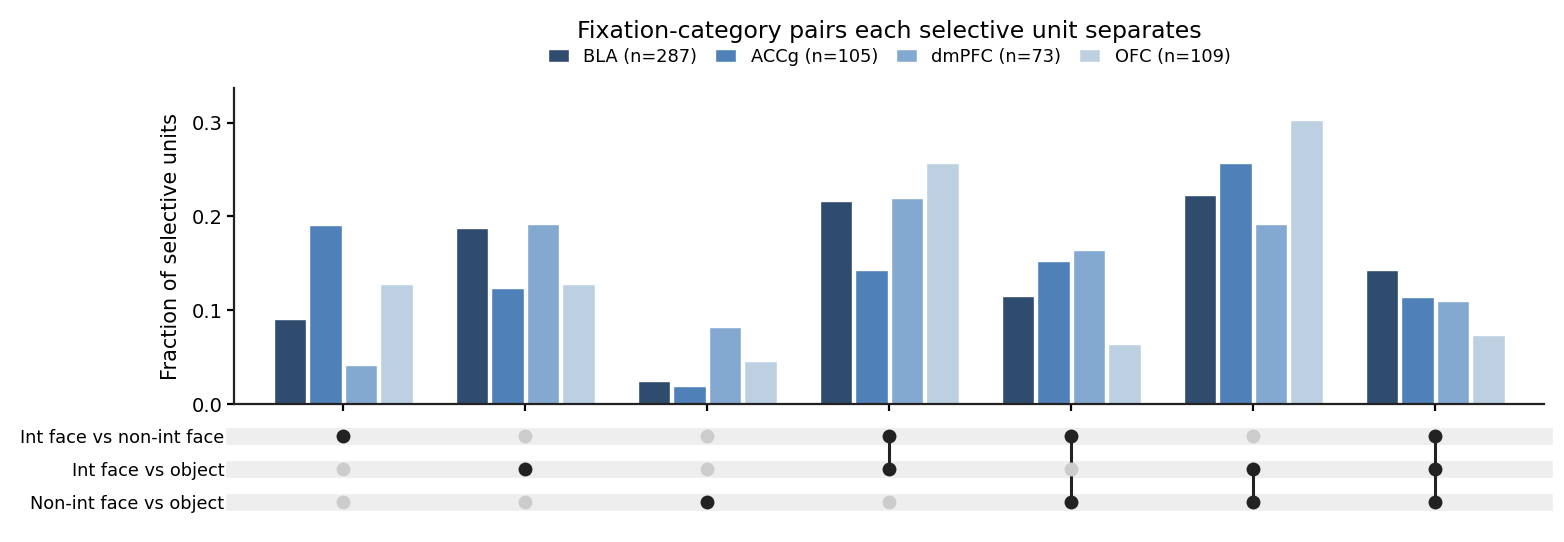

,region,region_label,100,010,001,110,101,011,111,n_selective,n_units
0,bla,BLA,26,54,7,62,33,64,41,287,537
1,accg,ACCg,20,13,2,15,16,27,12,105,236
2,dmpfc,dmPFC,3,14,6,16,12,14,8,73,187
3,ofc,OFC,14,14,5,28,7,33,8,109,241


In [5]:
pair_membership = figs.compute_pair_selectivity_membership(pair_selectivity)
fig, upset_counts = figs.plot_pair_selectivity_upset_panel(
    pair_membership,
    region_totals=units.groupby("region").size().to_dict(),
)
FIGURE_MANIFEST["fig03_pair_selectivity_upset"] = style.save_thesis_figure(
    fig, FIGURE_SETTINGS, "fig03_pair_selectivity_upset"
)
display(Image(data=style.figure_to_png_bytes(fig)))
display(upset_counts)

## 4 · Interactive face is still the preferred category

For each modulated unit, which category evoked the highest mean rate over the full
−500 to +500 ms window. Bars carry Wilson 95% intervals and a binomial test against
chance (1/3), FDR corrected across the region × category family; the pie inset shows
the composition, which cannot carry uncertainty and so is secondary.

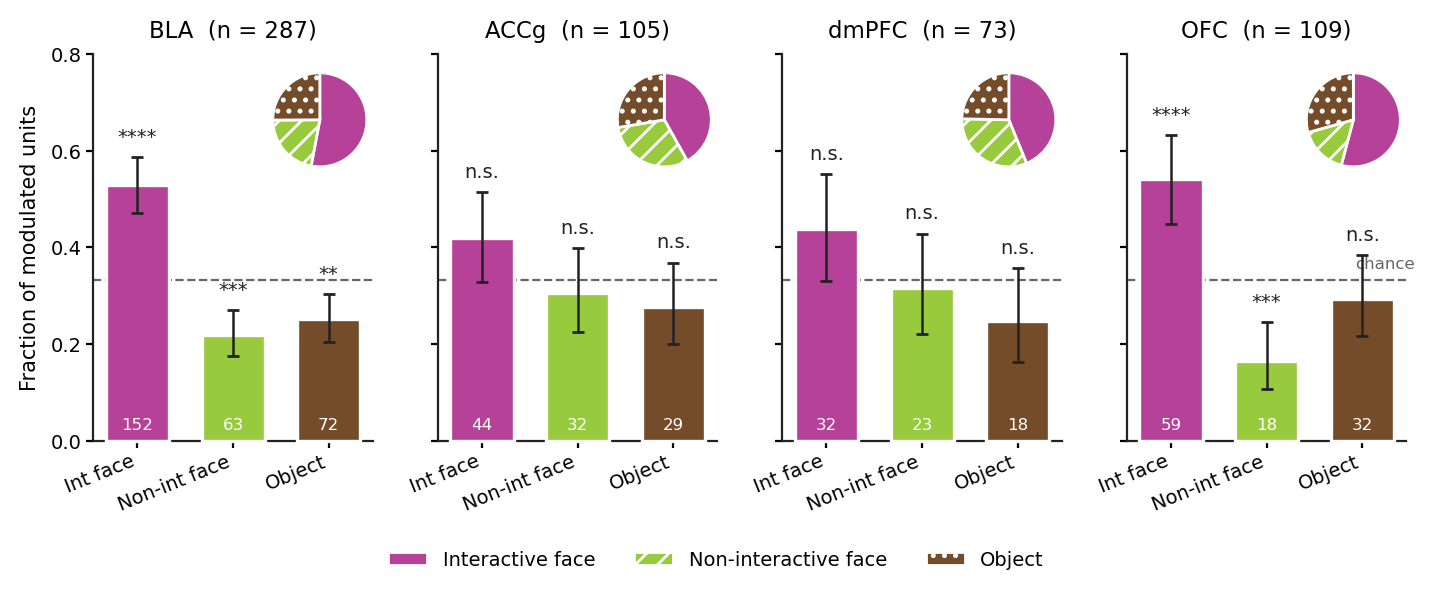

,region_label,condition,k,n,fraction,ci_low,ci_high,p_adj,stars
0,BLA,face_interactive,152,287,0.5296,0.4719,0.5866,0.0000,****
1,BLA,face_non_interactive,63,287,0.2195,0.1755,0.2709,0.0001,***
2,BLA,object,72,287,0.2509,0.2042,0.3041,0.0063,**
3,ACCg,face_interactive,44,105,0.4190,0.3292,0.5146,0.1333,n.s.
4,ACCg,face_non_interactive,32,105,0.3048,0.2249,0.3984,0.6600,n.s.
5,ACCg,object,29,105,0.2762,0.1997,0.3685,0.3395,n.s.
6,dmPFC,face_interactive,32,73,0.4384,0.3305,0.5524,0.1253,n.s.
7,dmPFC,face_non_interactive,23,73,0.3151,0.2200,0.4286,0.8047,n.s.
8,dmPFC,object,18,73,0.2466,0.1620,0.3564,0.2040,n.s.
9,OFC,face_interactive,59,109,0.5413,0.4479,0.6318,0.0001,****


In [6]:
fig, preference_table = figs.plot_preferred_condition_panel(units.loc[units["is_selective"]])
FIGURE_MANIFEST["fig04_preferred_condition"] = style.save_thesis_figure(
    fig, FIGURE_SETTINGS, "fig04_preferred_condition"
)
display(Image(data=style.figure_to_png_bytes(fig)))
display(
    preference_table.loc[
        :, ["region_label", "condition", "k", "n", "fraction", "ci_low", "ci_high",
            "p_adj", "stars"]
    ].round(4)
)

## 5 · Interactive-face responses are held longer

### Why not the coefficient of variation

The obvious statistic — the CV of the mean firing-rate trace across time bins — is
**not usable for comparing fixation categories here**. Interactive-face fixations are
about five times more numerous than the others (median 846 trials per unit versus
168 and 168). The number of time bins is identical in every condition, but that does
not protect the statistic: each bin of the mean trace is itself a trial average, so
writing `m(t) = s(t) + e(t)` gives

$$\operatorname{Var}_t[m] \approx \operatorname{Var}_t[s] + \mathbb{E}[\sigma^2]/N$$

and a condition observed with fewer trials inherits extra across-bin variance from
estimation noise alone.

The control below equalises trial counts within each unit and recomputes every
condition's CV from 25 matched subsamples. **The apparent interactive-face advantage
does not survive**: raw CV differs by a factor of two, matched CV is
indistinguishable. The right panel shows the mechanism directly — subsampling
interactive-face trials, holding condition and neural signal fixed, inflates that
condition's own CV by up to 2.4×.

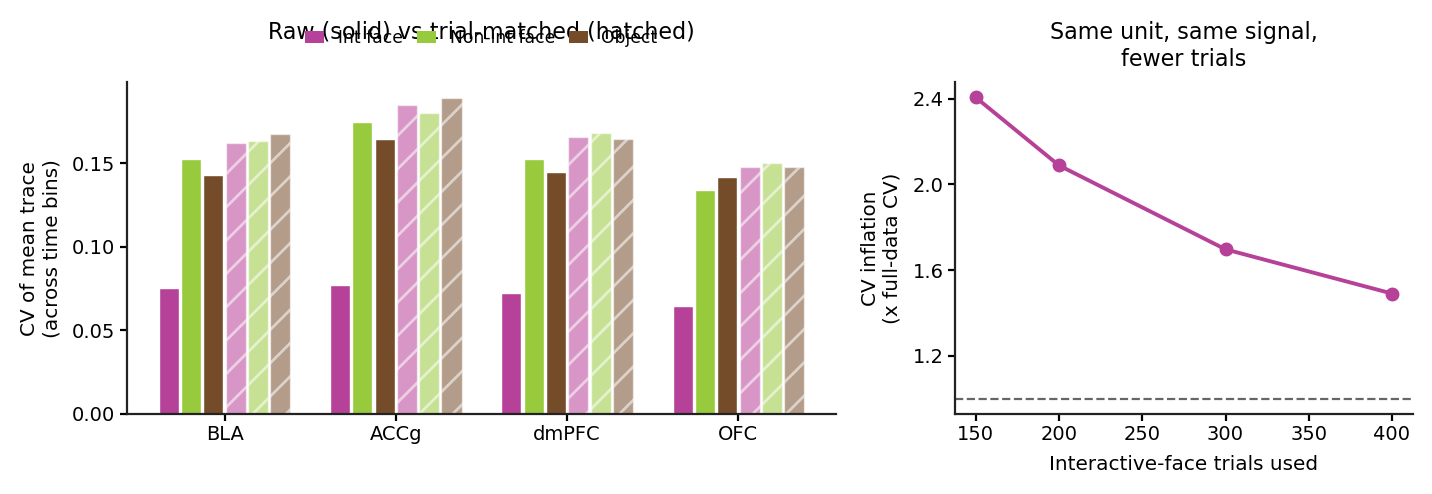

,region,variant,condition_b,n_units_paired,median_a,median_b,statistic,p_value_adjusted,significant_adjusted
0,ofc,cv_full,face_non_interactive,241,0.0646,0.1339,-18.3136,0.0000,True
1,ofc,cv_full,object,241,0.0646,0.1418,-16.7915,0.0000,True
3,ofc,cv_matched,face_non_interactive,241,0.1474,0.1502,-1.3319,0.2762,False
4,ofc,cv_matched,object,241,0.1474,0.1474,-2.5007,0.0314,True
6,bla,cv_full,face_non_interactive,537,0.0754,0.1522,-25.1123,0.0000,True
7,bla,cv_full,object,537,0.0754,0.1427,-20.4079,0.0000,True
9,bla,cv_matched,face_non_interactive,537,0.1618,0.1629,-1.7161,0.1735,False
10,bla,cv_matched,object,537,0.1618,0.1671,-2.6004,0.0314,True
12,accg,cv_full,face_non_interactive,236,0.0771,0.1746,-18.7120,0.0000,True
13,accg,cv_full,object,236,0.0771,0.1642,-17.0738,0.0000,True


In [7]:
fig = space.plot_cv_trial_matched_control(matched_cv, cv_inflation)
FIGURE_MANIFEST["fig05_cv_trial_matched_control"] = style.save_thesis_figure(
    fig, FIGURE_SETTINGS, "fig05_cv_trial_matched_control"
)
display(Image(data=style.figure_to_png_bytes(fig)))
display(
    matched_cv_stats.loc[
        matched_cv_stats["condition_a"] == "face_interactive",
        ["region", "variant", "condition_b", "n_units_paired", "median_a", "median_b",
         "statistic", "p_value_adjusted", "significant_adjusted"],
    ].round(4)
)

### Response duration, which is confound-free

**Response duration** — the full width at half maximum of the excess response — is a
width, not an amplitude, and is therefore near-insensitive to trial count
(Spearman ρ with log trial count = +0.12, against −0.76 for any prominence-based
score). Compared within unit across categories, it gives the defensible version of
the stability claim.

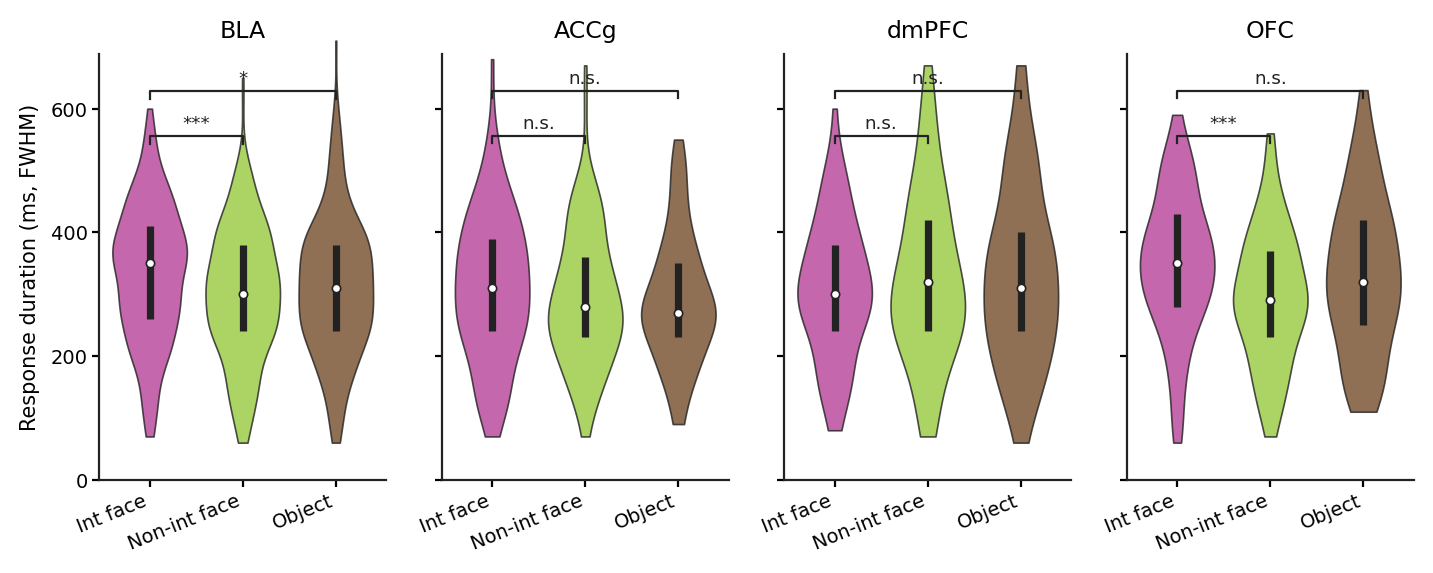

,region_label,condition_b,n_units,median_a,median_b,statistic,p_adj,stars
0,BLA,face_non_interactive,287,350.0,300.0,3.749,0.001,***
1,BLA,object,287,350.0,310.0,2.481,0.036,*
2,ACCg,face_non_interactive,105,310.0,280.0,1.075,0.380,n.s.
3,ACCg,object,105,310.0,270.0,1.472,0.288,n.s.
4,dmPFC,face_non_interactive,73,300.0,320.0,-0.884,0.380,n.s.
5,dmPFC,object,73,300.0,310.0,-0.918,0.380,n.s.
6,OFC,face_non_interactive,109,350.0,290.0,3.896,0.001,***
7,OFC,object,109,350.0,320.0,1.094,0.380,n.s.


In [8]:
fig, duration_table = figs.plot_condition_metric_panel(
    trace_shape_all.loc[trace_shape_all["is_selective"]],
    metric="response_duration_ms",
    metric_label=space.DURATION_LABEL,
)
FIGURE_MANIFEST["fig06_response_duration"] = style.save_thesis_figure(
    fig, FIGURE_SETTINGS, "fig06_response_duration"
)
display(Image(data=style.figure_to_png_bytes(fig)))
display(
    duration_table.loc[
        :, ["region_label", "condition_b", "n_units", "median_a", "median_b",
            "statistic", "p_adj", "stars"]
    ].round(3)
)

## 6 · Two axes describe the response, and there are no cell types

Each unit's response is summarised by two quantities measured on the trace of its
preferred category:

- **Response duration** — FWHM of the excess response (ms).
- **Peak isolation** — $1 - P_2/P_1$, where $P_1$ is the dominant peak's topographic
  prominence and $P_2$ the largest prominence at least 250 ms away. 1 means the peak
  has no rival; 0 means an equally strong second peak exists.

These replace the single composite score used previously. That composite,
$P_1/(1+\lambda P_2/P_1)$, correlates **0.99 with $P_1$ alone** — the discount term
spans too little range to matter — so it measured peak *height* while being
described as measuring isolation, and peak height is exactly the quantity trial
count corrupts. Duration and isolation are near-independent (ρ ≈ −0.26) and both
are trial-count insensitive (ρ = +0.12 and −0.001).

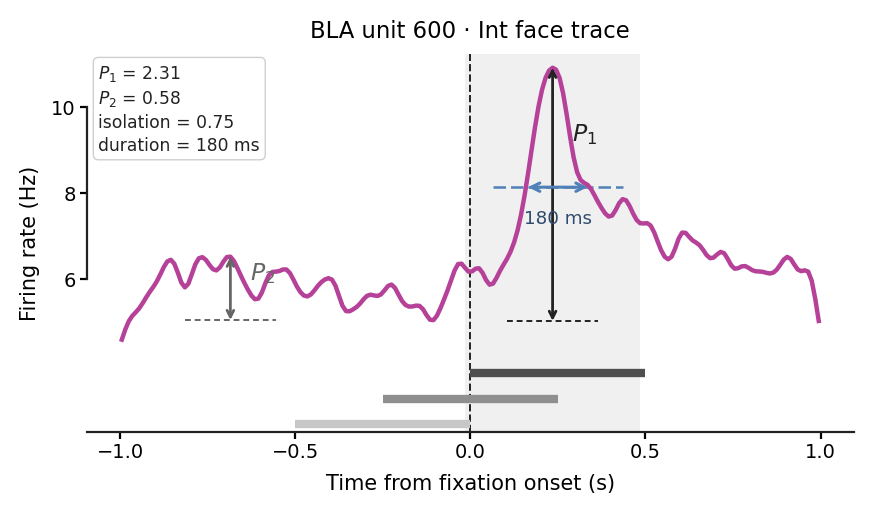

In [9]:
schematic_row = condition_traces.loc[
    (condition_traces["unit_uuid"] == "unit_uuid__600")
    & (condition_traces["condition"] == "face_interactive")
].iloc[0]
schematic_decomposition = decompose_dominant_peak_prominence(
    np.asarray(schematic_row["trace_hz"], dtype=float),
    np.asarray(schematic_row["bin_centers_s_rel"], dtype=float),
    peakiness_settings,
)
schematic_duration = float(
    trace_shape.loc[trace_shape["uuid"] == "600", "response_duration_ms"].iloc[0]
)
fig = space.plot_isolation_schematic(
    schematic_decomposition, unit_label="BLA unit 600", duration_ms=schematic_duration
)
FIGURE_MANIFEST["fig07_metric_schematic"] = style.save_thesis_figure(
    fig, FIGURE_SETTINGS, "fig07_metric_schematic"
)
display(Image(data=style.figure_to_png_bytes(fig)))

Plotted against each other, the modulated population forms a **single unimodal
cloud** in every region. There is no peaky/sustained dichotomy to threshold — which
is why the chapter treats these as descriptive axes rather than a taxonomy. Naming
the corners is still useful, and the units that occupy them are shown below.

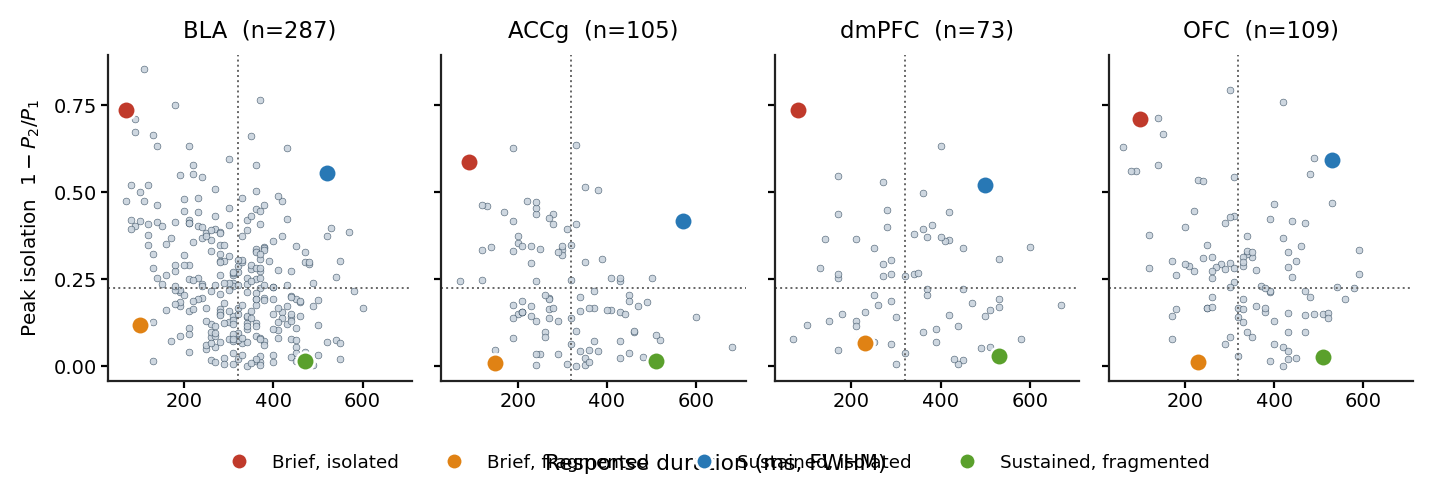

,region,n_units,duration_median_ms,isolation_median,spearman_rho
0,BLA,287,310.0,0.232,-0.298
1,ACCg,105,300.0,0.175,-0.314
2,dmPFC,73,340.0,0.205,-0.090
3,OFC,109,340.0,0.274,-0.275


In [10]:
corner_units = pd.concat(
    [space.select_corner_units(trace_shape, region=region) for region in style.REGION_ORDER],
    ignore_index=True,
)
fig, metric_space_summary = space.plot_metric_space_panel(trace_shape, corners=corner_units)
FIGURE_MANIFEST["fig08_metric_space"] = style.save_thesis_figure(
    fig, FIGURE_SETTINGS, "fig08_metric_space"
)
display(Image(data=style.figure_to_png_bytes(fig)))
display(metric_space_summary.round(3))

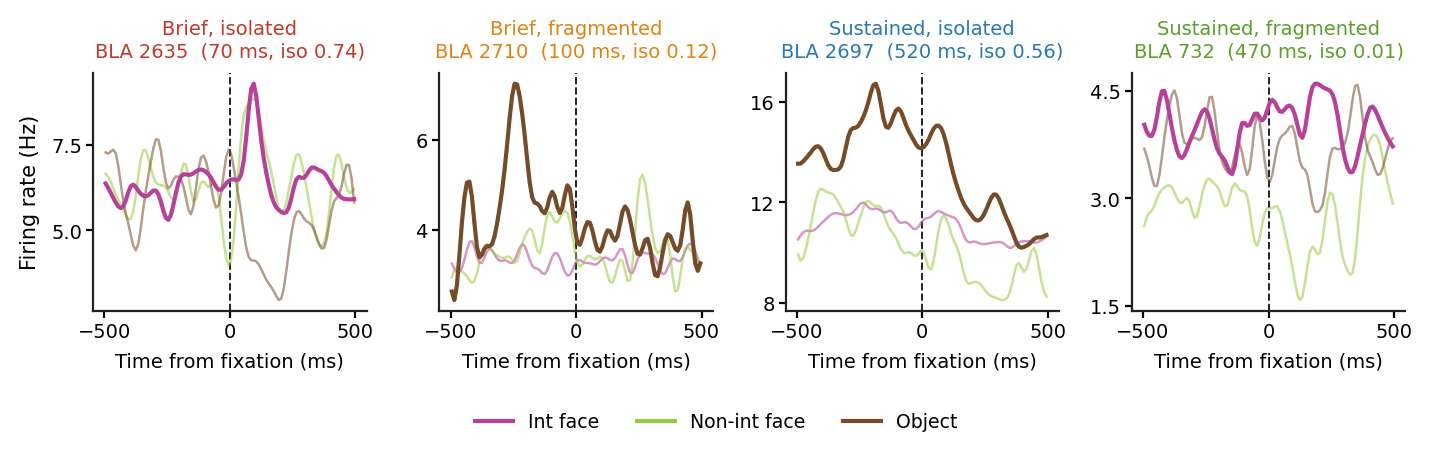

,region,corner,uuid,date,response_duration_ms,peak_isolation,mean_fr_hz
0,bla,"Brief, isolated",2635,1102019,70.0,0.74,6.28
1,bla,"Brief, fragmented",2710,1142019,100.0,0.12,4.31
2,bla,"Sustained, isolated",2697,1132019,520.0,0.56,12.80
3,bla,"Sustained, fragmented",732,8312018,470.0,0.01,3.94
4,accg,"Brief, isolated",380,1172019,90.0,0.59,3.28
5,accg,"Brief, fragmented",390,1172019,150.0,0.01,4.49
6,accg,"Sustained, isolated",129,1172018,570.0,0.42,22.31
7,accg,"Sustained, fragmented",335,1132019,510.0,0.01,12.24
8,dmpfc,"Brief, isolated",1771,1092019,80.0,0.74,5.14
9,dmpfc,"Brief, fragmented",1741,1082019,230.0,0.07,8.97


In [11]:
CORNER_REGION = "bla"
fig = space.plot_corner_example_traces(
    corner_units.loc[corner_units["region"] == CORNER_REGION], condition_traces
)
FIGURE_MANIFEST["fig09_corner_examples"] = style.save_thesis_figure(
    fig, FIGURE_SETTINGS, "fig09_corner_examples"
)
display(Image(data=style.figure_to_png_bytes(fig)))
display(
    corner_units.loc[
        :, ["region", "corner", "uuid", "date", "response_duration_ms", "peak_isolation",
            "mean_fr_hz"]
    ].round(2)
)

## 7 · Persist tables and figure manifest

In [12]:
exports = {
    "unit_yield_by_region.csv": yield_table,
    "pair_selectivity_upset_counts.csv": upset_counts,
    "preferred_condition_by_region.csv": preference_table,
    "response_duration_by_condition.csv": duration_table,
    "cv_trial_matched_stats.csv": matched_cv_stats,
    "metric_space_summary.csv": metric_space_summary,
    "metric_space_corner_units.csv": corner_units.loc[
        :, ["region", "corner", "uuid", "date", "response_duration_ms", "peak_isolation"]
    ],
    "interactive_face_examples.csv": example_units.loc[
        :, ["region", "uuid", "date", "subtitle", "dominant_condition"]
    ],
}
for filename, frame in exports.items():
    frame.to_csv(FIGURE_SETTINGS.output_dir / filename, index=False)
    print(f"wrote {filename:40s} ({len(frame)} rows)")

print()
for stem in FIGURE_MANIFEST:
    print(stem)

wrote unit_yield_by_region.csv                 (4 rows)
wrote pair_selectivity_upset_counts.csv        (4 rows)
wrote preferred_condition_by_region.csv        (12 rows)
wrote response_duration_by_condition.csv       (8 rows)
wrote cv_trial_matched_stats.csv               (24 rows)
wrote metric_space_summary.csv                 (4 rows)
wrote metric_space_corner_units.csv            (16 rows)
wrote interactive_face_examples.csv            (4 rows)

fig01_interactive_face_examples
fig02_unit_yield
fig03_pair_selectivity_upset
fig04_preferred_condition
fig05_cv_trial_matched_control
fig06_response_duration
fig07_metric_schematic
fig08_metric_space
fig09_corner_examples


## Summary

1. **Individual neurons prefer interactive face fixations** (§2). The four example
   units each separate interactive face from both other categories and fire most for
   it throughout the fixation.
2. **But they are not category-specific detectors** (§3). Most modulated units
   separate two or three of the three pairs; the single-pair combinations are the
   minority everywhere.
3. **Interactive face is the modal preference** (§4), significantly above chance in
   BLA and OFC and numerically leading in ACCg and dmPFC.
4. **Interactive-face responses last longer** (§5) — BLA 350 vs 300/310 ms, OFC 350
   vs 290 ms. The coefficient of variation, which appears to show a far larger
   effect, is not usable: the difference is created by interactive face having ~5×
   more trials, and it vanishes under trial matching.
5. **Response shape is continuous, not categorical** (§6). Duration and peak
   isolation are independent and both unimodal; naming corners of that space is
   descriptive convenience, not a cell-type claim.

The appendix (`single_unit_trace_metrics_appendix.ipynb`) reports the wider set of
trace metrics, which of them are redundant, and how each relates to these two.